# 5a. Full workflow: Marianas arc data

Here's an example of a full workflow to explore melt inclusion and matrix glass data using VolFe. We'll calculate saturation pressures, degassing paths, isobars, and *f*<sub>O<sub>2</sub></sub> from sulfur content from a single csv file in one notebook. We also compare to some of the other degassing tools available. This example is used in Hughes et al. (pre-print).

## Python set-up
First we need to import a few Python packages (including VolFe). You need to install VolFe (and the other packages such as ThermoBar) once on your machine. If you haven't yet, uncomment the line below (remove the # for the lines beginning !pip).

In [1]:
# Install VolFe and Thermobar on your machine if you have not done so already. Remove the # from lines below to do this (don't remove the # from this line!).
# !pip install VolFe
# !pip install Thermobar
# !pip install VESIcal

In [1]:
# import python packages
import pandas as pd
import numpy as np
import VolFe as vf
import Thermobar as tb
import VESIcal as vc
import matplotlib.pyplot as plt

c:\Users\ehughes\AppData\Local\miniforge3\envs\volfe-dev\Lib\site-packages\VESIcal\calculate_classes.py:7: UserWarning: 

  from VESIcal.models import magmasat


Check version numbers

In [ ]:
# VolFe
vf.__version__

In [ ]:
# Thermobar
tb.__version__

In [ ]:
# VESIcal
vc.__version__

## Import data

First we will load our data from a csv file. We'll use the examples_marianas csv in files again from Brounce et al. (2014, 2016) and Kelley & Cottrell (2012).

In [2]:
my_analyses = pd.read_csv("../files/example_marianas.csv")  # load data

## Calculate temperature using Thermobar

All VolFe calculations require a temperature. We calculate temperature for each glass analysis using eq. (14) from Putirka (2008), which depends on melt composition including water but not pressure, using ThermoBar (Wieser et al. 2022). This is then added to the dataframe of compositions.

In [3]:
# renames melt composition headers to be comparible with Thermobar
my_analyses_tb = my_analyses.rename(columns = {"SiO2":"SiO2_Liq","TiO2":"TiO2_Liq","Al2O3":"Al2O3_Liq","FeOT":"FeOt_Liq","MnO":"MnO_Liq","MgO":"MgO_Liq","CaO":"CaO_Liq",
                                               "Na2O":"Na2O_Liq","K2O":"K2O_Liq","P2O5":"P2O5_Liq","H2O":"H2O_Liq"})
# calculates T using Thermobar based on eq. (14) from Putirka (2008) and converts to 'C
T_C_all = tb.calculate_liq_only_temp(liq_comps=my_analyses_tb, equationT="T_Put2008_eq14")-273.15
# adds temperatures to original dataframe
my_analyses.insert(1,"T_C",T_C_all)

Later on, we also require the error associated with the temperature - the reported SEE for this thermometer is 51 'C, which we add to the dataframe as well as a column stating the error is absolute rather than than relative.

In [4]:
my_analyses['T_C_sd'] = 51.
my_analyses['T_C_sd_type'] = 'A'

## Calculate the pressure of vapor-saturation

Now we can calculate the pressure of vapor saturation for all the analyses in the file using the default models in VolFe.

In [ ]:
# run calculation
pvsat = vf.calc_Pvsat(my_analyses)
# save results
pvsat.to_csv('../files/marianas_pvsat.csv', index=False, header=True)
# load result
pvsat = pd.read_csv("../files/marianas_pvsat.csv")

## Calculate the *f*<sub>O<sub>2</sub></sub> from the sulfur content

Instead of using the Fe<sup>3+</sup>/Fe<sub>T</sub> measured in the glass to calculate *f*<sub>O<sub>2</sub></sub>, we can instead use the measured S content and compare it too the S<sup>2-</sup>CSS.

In [ ]:
# run calculation
fO2fromS = vf.calc_melt_S_oxybarometer(my_analyses)
# save results
fO2fromS.to_csv('../files/marianas_fO2fromS.csv', index=False, header=True)
# load result
fO2fromS = pd.read_csv("../files/marianas_fO2fromS.csv")

## Influence of melt composition errors

Next we look at how errors in the melt composition might influence the calculations we have done: pvsat and fO2 from measured S. We use a Monte Carlo approach to calculate 100 potential compositions of each MI/SPG to see how that effects our calculations.

In [6]:
# run calculation
#pvsat_all_errors = vf.calc_comp_error_function(my_analyses,iterations=100,function='calc_Pvsat')
# save results
#pvsat_all_errors.to_csv('../files/marianas_pvsat_all_errors.csv', index=False, header=True)
# load result
pvsat_all_errors = pd.read_csv("../files/marianas_pvsat_all_errors.csv")

In [7]:
# run calculation
#S2fO2_all_errors = vf.calc_comp_error_function(my_analyses,iterations=100,function='calc_melt_S_oxybarometer')
# save results
#S2fO2_all_errors.to_csv('../files/marianas_S2fO2_all_errors.csv', index=False, header=True)
# load result
S2fO2_all_errors = pd.read_csv("../files/marianas_S2fO2_all_errors.csv")

## Calculate isobars

We can also calculate isobars for Ala02-16A but we need to change the "insolubles" option to "H2O-CO2 only" to do this.

In [8]:
# change just the "COH_species" option to "H2O-CO2 only"
my_models = [['COH_species','H2O-CO2 only']]
# turn "my_models" to dataframe with correct column headers and indexes    
my_models = vf.make_df_and_add_model_defaults(my_models)
# calculate isobars for Ala01-16A which is run 29 in the csv starting at 1000 bars, ending at 4000 bars at 1000 bar intervals
#isobars = vf.calc_isobar(my_analyses,run=29,models=my_models,initial_P=1000.,final_P=5000.,step_P=1000.)
# save results
#isobars.to_csv('../files/marianas_isobars.csv', index=False, header=True)
# load result
isobars = pd.read_csv("../files/marianas_isobars.csv")
# split into each pressure for plotting
isobar1000 = isobars[isobars["P_bar"]==1000.]
isobar2000 = isobars[isobars["P_bar"]==2000.]
isobar3000 = isobars[isobars["P_bar"]==3000.]
isobar4000 = isobars[isobars["P_bar"]==4000.]
isobar5000 = isobars[isobars["P_bar"]==5000.]

## Calculate de/regassing paths

### Closed-system, melt-only, degassing

Next we can run a closed-system degassing calculation starting from Ala02-16A, using the default options.

In [9]:
# run calculation
#degassing_closed_1 = vf.calc_gassing(my_analyses,run=29)
# save result
#degassing_closed_1.to_csv('../files/marianas_degas_closed_1.csv', index=False, header=True)
# load result
degassing_closed_1 = pd.read_csv("../files/marianas_degas_closed_1.csv")

### Closed-system, melt+vapor, degassing

But it probably had more CO<sub>2</sub> to start with... so we can run a closed-system degassing calculation assuming the initial melt contained 2 wt% CO<sub>2</sub>.

In [10]:
# 'bulk composition' to 'melt+vapor_initialCO2'
my_models = [['bulk_composition',"melt+vapor_initialCO2"]]

# turn to dataframe with correct column headers and indexes    
my_models = vf.make_df_and_add_model_defaults(my_models)

# run calculation
#degassing_closed_2 = vf.calc_gassing(my_analyses,run=29,models=my_models)
# save result
#degassing_closed_2.to_csv('../files/marianas_degas_closed_2.csv', index=False, header=True)
# load result
degassing_closed_2 = pd.read_csv("../files/marianas_degas_closed_2.csv")

### Closed-system, melt+gas, regassing

... and regas along the same path to see how it would have evolved at higher pressures before the melt inclusion was formed.

In [11]:
# change to regas and melt+vapor_initialCO2
my_models = [['gassing_direction','regas'],['bulk_composition',"melt+vapor_initialCO2"]]

# turn to dataframe with correct column headers and indexes    
my_models = vf.make_df_and_add_model_defaults(my_models)

# run calculation
#regassing_closed_2 = vf.calc_gassing(my_analyses,run=29,models=my_models)
# save result
#regassing_closed_2.to_csv('../files/marianas_regas_closed_2.csv', index=False, header=True)
# load result
regassing_closed_2 = pd.read_csv("../files/marianas_regas_closed_2.csv")

### Open-system degassing

And we can compare it to open-system degassing...

In [12]:
# change just the "COH_species" option to "H2O-CO2 only"
my_models = [['gassing_style','open']]

# turn to dataframe with correct column headers and indexes    
my_models = vf.make_df_and_add_model_defaults(my_models)

# run calculation
#degassing_open = vf.calc_gassing(my_analyses,run=29,models=my_models)
# save result
#degassing_open.to_csv('../files/marianas_degas_open.csv', index=False, header=True)
# load result
degassing_open = pd.read_csv("../files/marianas_degas_open.csv")

### Open-system regassing

... and open-system regassing ...

In [13]:
# change just the "COH_species" option to "H2O-CO2 only"
my_models = [['gassing_style','open'],['gassing_direction','regas']]

# turn to dataframe with correct column headers and indexes    
my_models = vf.make_df_and_add_model_defaults(my_models)

# run calculation
#regassing_open = vf.calc_gassing(my_analyses,run=29,models=my_models)
# save result
#regassing_open.to_csv('../files/marianas_regas_open.csv', index=False, header=True)
# load result
regassing_open = pd.read_csv("../files/marianas_regas_open.csv")

## Comparison to other tools

We can compare the results of the closed-system, melt-only, degassing calculation to the results from other tools that are available.

### VESIcal (Iacovino et al., 2021)

Using the VolatileCalc model (Newman & Lowerstern, 2022), which is closest to the model dependent variable options used in the VolFe calculation.

In [14]:
my_sample = vc.Sample({'SiO2':  43.97,
 'TiO2':   0.7,
 'Al2O3': 19.09,
 'Fe2O3':  0.,
 'Cr2O3':  0.0,
 'FeO':    9.36,
 'MnO':    0.22,
 'MgO':    6.76,
 'NiO':    0.0,
 'CoO':    0.0,
 'CaO':    13.28,
 'Na2O':   1.46,
 'K2O':    0.37,
 'P2O5':   0.11,
 'H2O':    4.32,
 'CO2':    0.0999})

# run degassing calculation
#vesical_volatilecalc = vc.calculate_degassing_path(sample=my_sample,temperature=1111.,model='Dixon').result
# save result
#vesical_volatilecalc.to_csv('../files/comparison/vesical_volatilecalc.csv', index=False, header=True)
# load result
vesical_volatilecalc = pd.read_csv("../files/comparison/vesical_volatilecalc.csv")

### Sulfur_X (Ding et al., 2023)

Initial conditions and model options can be found in 'main_Fuego.py' and 'melt_composition.py'.

In [15]:
sulfur_X = pd.read_csv("../files/comparison/sulfur_X.csv")  # load data

### CHOSETTO (Moretti et al., 2003; Moretti & Papale, 2004)

Initial conditions and model options can be found in "chosetto.ctr" and "chosetto.dat". The original output (chosetto.out) was converted to csv, D was replaced with E throughout, and column headers were added.

In [16]:
chosetto = pd.read_csv("../files/comparison/chosetto.csv")  # load data

In [17]:
x = (chosetto['FeO_Fe2O3']*2.*159.69)/71.844
chosetto_Fe3_FeT = 1.-(x/(x+1.))

### EVo (Liggins et al., 2022, 2020)

Initial conditions can be found in 'env_ery.yaml' and 'chem_ery.yaml'.

In [19]:
evo = pd.read_csv("../files/comparison/dgs_output_basalt_COHS_closed_1384K.csv")  # load data

## Plotting

Finally, we can plot all everything!

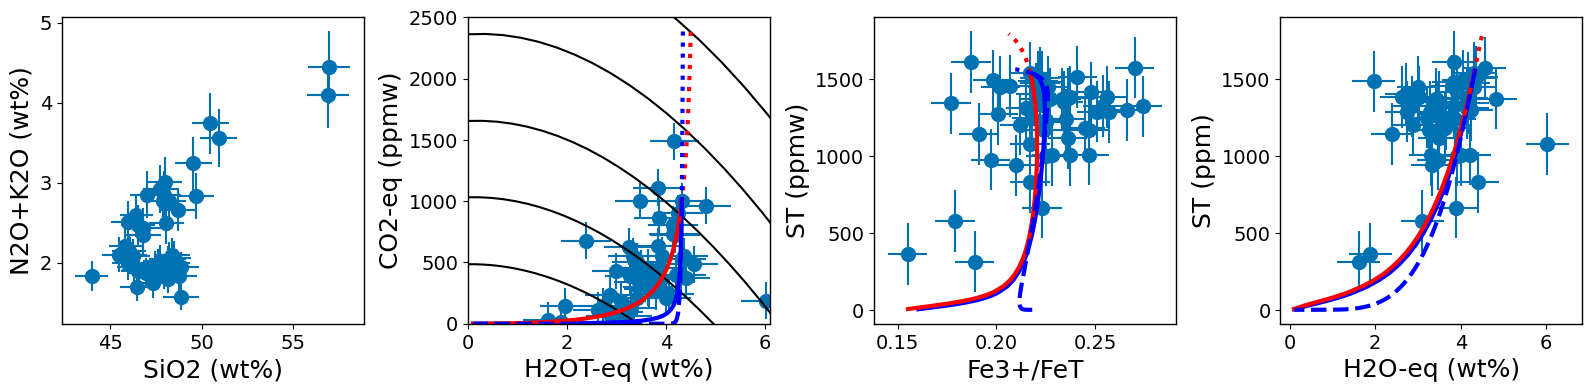

In [36]:
fig, (ax1,ax2,ax3,ax4) = plt.subplots(1, 4, figsize=(16,4))

# TAS
ax1.errorbar(my_analyses['SiO2'], y=(my_analyses['K2O']+my_analyses['Na2O']), 
             xerr=((2.*my_analyses["SiO2_sd"])*my_analyses["SiO2"]), yerr=(2*(my_analyses["Na2O_sd"]**2+my_analyses["K2O_sd"]**2.)**0.5)*(my_analyses["K2O"]+my_analyses["Na2O"]), 
             fmt='o')
ax1.set_ylabel('N2O+K2O (wt%)')
ax1.set_xlabel('SiO2 (wt%)')

# H2O-CO2
for x in [isobar1000,isobar2000,isobar3000,isobar4000,isobar5000]:
    ax2.plot(x["H2O_wtpc"], x["CO2_ppm"], '-k')
ax2.errorbar(my_analyses['H2O'], y=my_analyses['CO2ppm'], xerr=(2.*my_analyses['H2O_sd']), yerr=(2*my_analyses["CO2ppm_sd"]), fmt='o', zorder=0)
ax2.plot(degassing_closed_1['H2OT-eq_wtpc'], degassing_closed_1['CO2T-eq_ppmw'], '-b', linewidth=3.)
ax2.plot(degassing_closed_2['H2OT-eq_wtpc'], degassing_closed_2['CO2T-eq_ppmw'], '-r', linewidth=3.)
ax2.plot(regassing_closed_2['H2OT-eq_wtpc'], regassing_closed_2['CO2T-eq_ppmw'], ':r', linewidth=3.)
ax2.plot(regassing_open['H2OT-eq_wtpc'], regassing_open['CO2T-eq_ppmw'], ':b', linewidth=3.)
ax2.plot(degassing_open['H2OT-eq_wtpc'], degassing_open['CO2T-eq_ppmw'], '--b', linewidth=3.)
ax2.set_xlabel('H2OT-eq (wt%)')
ax2.set_ylabel('CO2-eq (ppmw)')
ax2.set_ylim([0,2500])
ax2.set_xlim([0,6.1])

# Fe3+/FeT-ST
ax3.errorbar(my_analyses['Fe3FeT'], y=my_analyses['STppm'], xerr=(2.*my_analyses['Fe3FeT_sd']), yerr=(2*my_analyses["STppm_sd"]), fmt='o', zorder=0)
ax3.plot(degassing_closed_1['Fe3+/FeT'], degassing_closed_1['ST_ppmw'], '-b', linewidth=3.)
ax3.plot(degassing_closed_2['Fe3+/FeT'], degassing_closed_2['ST_ppmw'], '-r', linewidth=3.)
ax3.plot(regassing_closed_2['Fe3+/FeT'], regassing_closed_2['ST_ppmw'], ':r', linewidth=3.)
ax3.plot(regassing_open['Fe3+/FeT'], regassing_open['ST_ppmw'], ':b', linewidth=3.)
ax3.plot(degassing_open['Fe3+/FeT'], degassing_open['ST_ppmw'], '--b', linewidth=3.)
ax3.set_xlabel('Fe3+/FeT')
ax3.set_ylabel('ST (ppmw)')
 

# H2O-ST
ax4.errorbar(my_analyses['H2O'], y=my_analyses['STppm'], xerr=(2.*my_analyses['H2O_sd']), yerr=(2*my_analyses["STppm_sd"]), fmt='o', zorder=0)
ax4.plot(degassing_closed_1['H2OT-eq_wtpc'], degassing_closed_1['ST_ppmw'], '-b', linewidth=3.)
ax4.plot(degassing_closed_2['H2OT-eq_wtpc'], degassing_closed_2['ST_ppmw'], '-r', linewidth=3.)
ax4.plot(regassing_closed_2['H2OT-eq_wtpc'], regassing_closed_2['ST_ppmw'], ':r', linewidth=3.)
ax4.plot(regassing_open['H2OT-eq_wtpc'], regassing_open['ST_ppmw'], ':b', linewidth=3.)
ax4.plot(degassing_open['H2OT-eq_wtpc'], degassing_open['ST_ppmw'], '--b', linewidth=3.)
ax4.set_xlabel('H2O-eq (wt%)')
ax4.set_ylabel('ST (ppm)')
fig.tight_layout(pad=1.0)

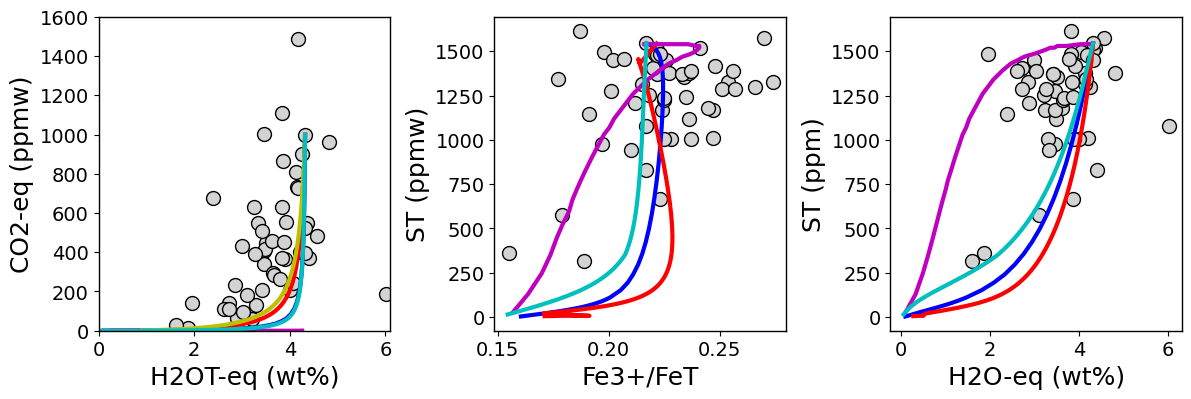

In [37]:
fig, (ax1,ax2,ax3) = plt.subplots(1, 3, figsize=(12,4))

# H2O-CO2
ax1.plot(my_analyses['H2O'], my_analyses['CO2ppm'], 'ok', mfc='lightgrey')
ax1.plot(degassing_closed_1['H2OT-eq_wtpc'], degassing_closed_1['CO2T-eq_ppmw'], '-b', linewidth=3.)
ax1.plot(sulfur_X['wH2O_melt'], sulfur_X['wCO2_melt'], '-r', linewidth=3.)
ax1.plot(chosetto['wm_H2O']*100., chosetto['wm_CO2']*100000., '-m', linewidth=3.)
ax1.plot(vesical_volatilecalc['H2O_liq'], vesical_volatilecalc['CO2_liq']*10000., '-y', linewidth=3.)
ax1.plot(evo['H2O_melt'], evo['CO2_melt']*10000., '-c', linewidth=3.)
ax1.set_xlabel('H2OT-eq (wt%)')
ax1.set_ylabel('CO2-eq (ppmw)')
ax1.set_ylim([0,1600])
ax1.set_xlim([0,6.1])

# Fe3+/FeT-ST
ax2.plot(my_analyses['Fe3FeT'], my_analyses['STppm'], 'ok', mfc='lightgrey')
ax2.plot(degassing_closed_1['Fe3+/FeT'], degassing_closed_1['ST_ppmw'], '-b', linewidth=3.)
ax2.plot(sulfur_X['ferric_ratio'], sulfur_X['wS_melt'], '-r', linewidth=3.)
ax2.plot(chosetto_Fe3_FeT, chosetto['wm_S']*1000000., '-m', linewidth=3.)
ax2.plot(evo['Fe3FeT'], evo['Stot_melt']*10000., '-c', linewidth=3.)
ax2.set_xlabel('Fe3+/FeT')
ax2.set_ylabel('ST (ppmw)')
 

# H2O-ST
ax3.plot(my_analyses['H2O'], my_analyses['STppm'], 'ok', mfc='lightgrey')
ax3.plot(degassing_closed_1['H2OT-eq_wtpc'], degassing_closed_1['ST_ppmw'], '-b', linewidth=3.)
ax3.plot(sulfur_X['wH2O_melt'], sulfur_X['wS_melt'], '-r', linewidth=3.)
ax3.plot(chosetto['wm_H2O']*100., chosetto['wm_S']*1000000., '-m', linewidth=3.)
ax3.plot(evo['H2O_melt'], evo['Stot_melt']*10000., '-c', linewidth=3.)
ax3.set_xlabel('H2O-eq (wt%)')
ax3.set_ylabel('ST (ppm)')
fig.tight_layout(pad=1.0)

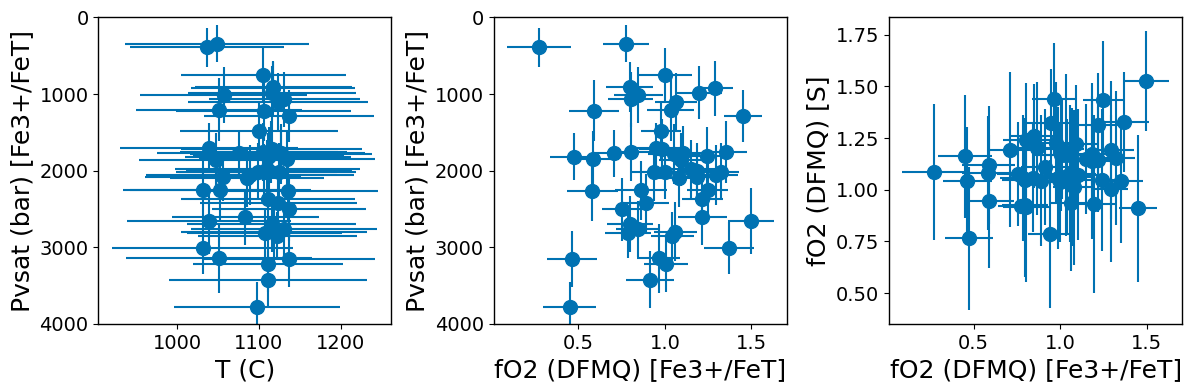

In [43]:
fig, (ax1,ax2,ax3) = plt.subplots(1, 3, figsize=(12,4))

# P-T
ax1.errorbar(pvsat_all_errors['T_C'], y=pvsat_all_errors['P_bar'], 
             xerr=(2.*pvsat_all_errors['T_C_sd']), yerr=(2*pvsat_all_errors["P_bar_sd"]), fmt='o', zorder=0)
ax1.set_ylabel('Pvsat (bar) [Fe3+/FeT]')
ax1.set_xlabel('T (C)')
ax1.set_ylim([4000,0])

# P-fO2[Fe3+/FeT]
ax2.errorbar(pvsat_all_errors['fO2_DFMQ'], y=pvsat_all_errors['P_bar'], 
             xerr=(2.*pvsat_all_errors['fO2_DFMQ_sd']), yerr=(2*pvsat_all_errors["P_bar_sd"]), fmt='o', zorder=0)
ax2.set_ylabel('Pvsat (bar) [Fe3+/FeT]')
ax2.set_xlabel('fO2 (DFMQ) [Fe3+/FeT]')
ax2.set_ylim([4000,0])

# fO2[S]-fO2[Fe3+/FeT]
ax3.errorbar(pvsat_all_errors['fO2_DFMQ'], y=S2fO2_all_errors['fO2_DFMQ_sulf'], 
             xerr=(2.*pvsat_all_errors['fO2_DFMQ_sd']), yerr=(2*S2fO2_all_errors['fO2_DFMQ_sulf_sd']), fmt='o', zorder=0)
ax3.set_ylabel('fO2 (DFMQ) [S]')
ax3.set_xlabel('fO2 (DFMQ) [Fe3+/FeT]')

fig.tight_layout(pad=1.0)

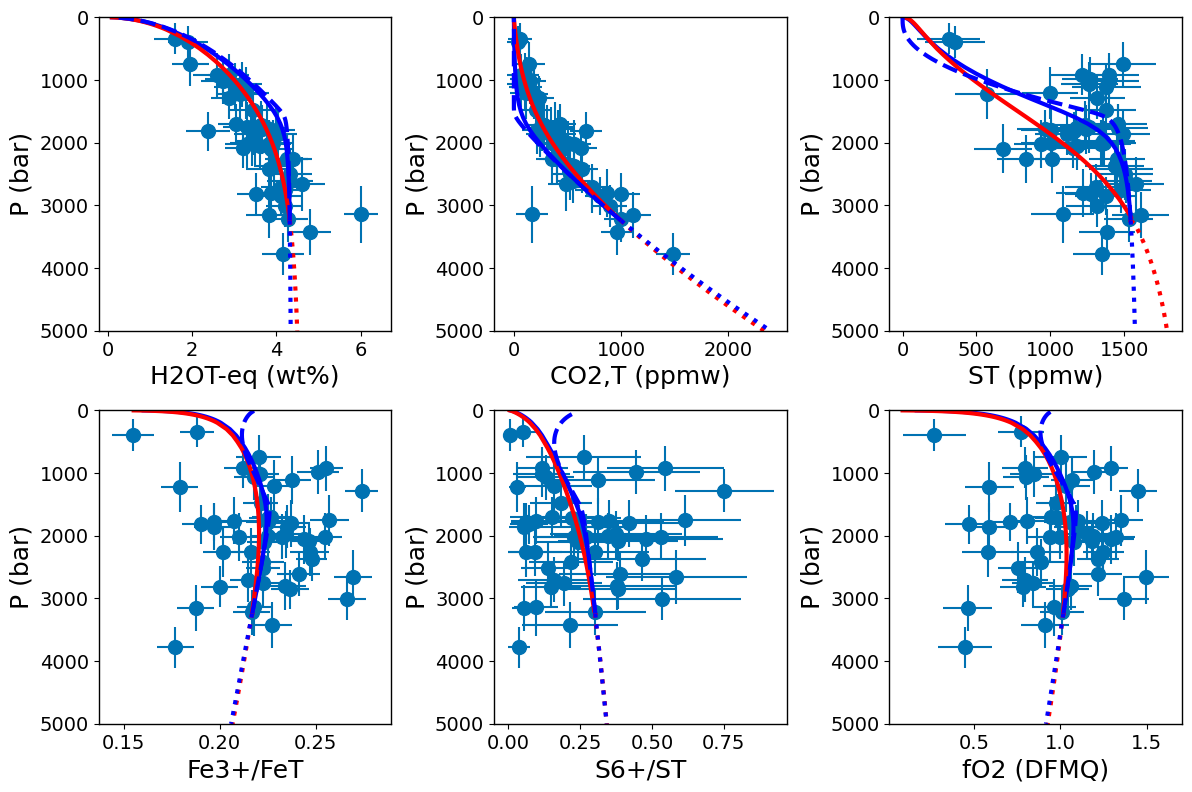

In [38]:
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6)) = plt.subplots(2, 3, figsize=(12,8))

for x in [ax1,ax2,ax3,ax4,ax5,ax6]:
    if x == ax1:
        value = 'H2OT-eq_wtpc'
        x.set_xlabel('H2OT-eq (wt%)')
    elif x == ax2:
        value = 'CO2T-eq_ppmw'
        x.set_xlabel('CO2,T (ppmw)')
    elif x == ax3:
        value = 'ST_ppmw'
        x.set_xlabel('ST (ppmw)')
    elif x == ax4:
        value = 'Fe3+/FeT'
        x.set_xlabel('Fe3+/FeT')
    elif x == ax5:
        value = 'S6+/ST'
        x.set_xlabel('S6+/ST')
    elif x == ax6:
        value = 'fO2_DFMQ'
        x.set_xlabel('fO2 (DFMQ)')
    x.errorbar(pvsat_all_errors[value], y=pvsat_all_errors['P_bar'], xerr=(2.*pvsat_all_errors[value+'_sd']), yerr=(2*pvsat_all_errors["P_bar_sd"]), fmt='o', zorder=0)
    x.plot(degassing_closed_1[value], degassing_closed_1['P_bar'], '-b', linewidth=3.)
    x.plot(degassing_closed_2[value], degassing_closed_2['P_bar'], '-r', linewidth=3.)
    x.plot(regassing_closed_2[value], regassing_closed_2['P_bar'], ':r', linewidth=3.)
    x.plot(regassing_open[value], regassing_open['P_bar'], ':b', linewidth=3.)
    x.plot(degassing_open[value], degassing_open['P_bar'], '--b', linewidth=3.)
    x.set_ylabel('P (bar)')
    x.set_ylim([5000,0])

fig.tight_layout(pad=1.0)

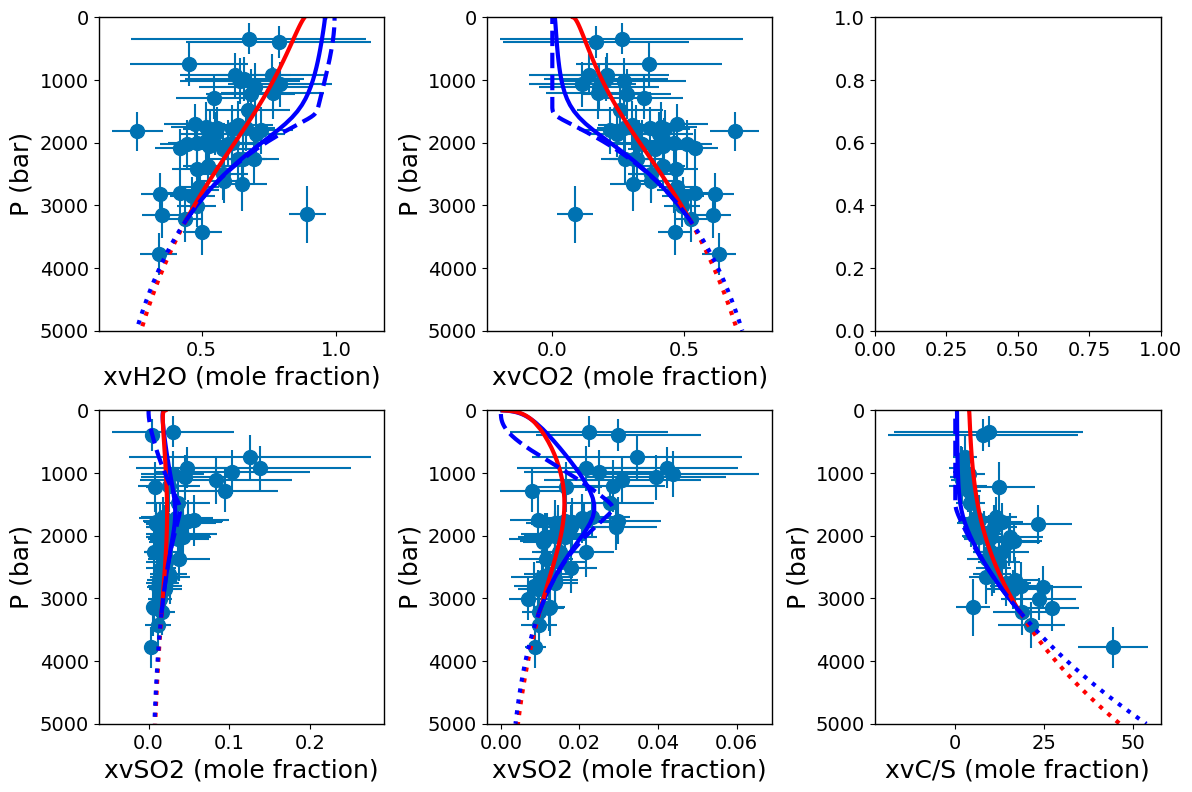

In [44]:
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6)) = plt.subplots(2, 3, figsize=(12,8))

for x in [ax1,ax2,ax4,ax5,ax6]:
    if x == ax1:
        value = 'xgH2O_mf'
        x.set_xlabel('xvH2O (mole fraction)')
    elif x == ax2:
        value = 'xgCO2_mf'
        x.set_xlabel('xvCO2 (mole fraction)')
    elif x == ax4:
        value = 'xgSO2_mf'
        x.set_xlabel('xvSO2 (mole fraction)')
    elif x == ax5:
        value = 'xgH2S_mf'
        x.set_xlabel('xvSO2 (mole fraction)')
    elif x == ax6:
        value = 'xgC_S_mf'
        x.set_xlabel('xvC/S (mole fraction)')
    x.errorbar(pvsat_all_errors[value], y=pvsat_all_errors['P_bar'], xerr=(2.*pvsat_all_errors[value+'_sd']), yerr=(2*pvsat_all_errors["P_bar_sd"]), fmt='o', zorder=0)
    x.plot(degassing_closed_1[value], degassing_closed_1['P_bar'], '-b', linewidth=3.)
    x.plot(degassing_closed_2[value], degassing_closed_2['P_bar'], '-r', linewidth=3.)
    x.plot(regassing_closed_2[value], regassing_closed_2['P_bar'], ':r', linewidth=3.)
    x.plot(regassing_open[value], regassing_open['P_bar'], ':b', linewidth=3.)
    x.plot(degassing_open[value], degassing_open['P_bar'], '--b', linewidth=3.)
    x.set_ylabel('P (bar)')
    x.set_ylim([5000,0])

fig.tight_layout(pad=1.0)